Say you've been iterating on a prompt for a **support ticket classifier**: a backend system that routes incoming customer requests into one of four queues: `BILLING`, `TECHNICAL`, `ACCOUNT`, or `GENERAL`. The system needs to run fast, so you're targeting a small local model, `gemma3:1b`.

You've tried eight prompt variants: a zero-shot baseline, a role-framed version, one with explicit category definitions, two few-shot variants (1- and 3-example), a chain-of-thought approach, one that returns JSON, and one with negative framing ("do *not* confuse BILLING with ACCOUNT").

After running an eval on 20 labeled examples, here are the mean accuracies per prompt:

P0_baseline                   45.0%
P1_role                       50.0%
P2_definitions                40.0%
P3_few_shot_1                 40.0%
P4_few_shot_3                 45.0%
P5_chain_of_thought           45.0%
P6_json_output                55.0%
P7_negative_framing           25.0%


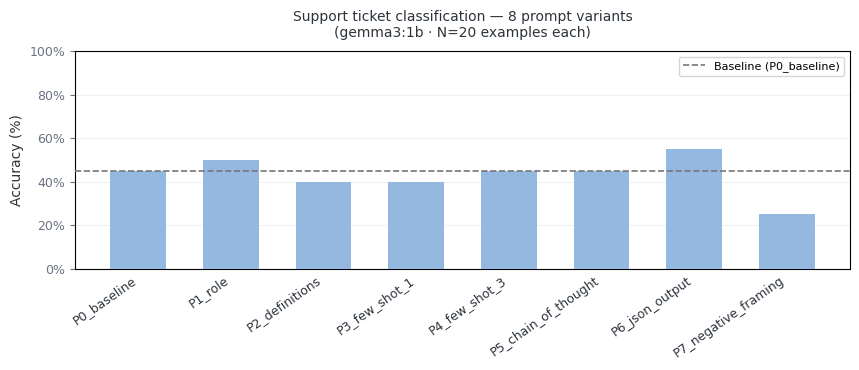

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import promptstats as pstats
pstats.set_alpha_ci(0.05)  # Use 95% CIs throughout this notebook (package default is 99%)

# Load eval results.
# Columns: prompt_id, input_id, ticket, category, output, predicted, correct
df = pd.read_csv("support_ticket_eval_20.csv")
def get_scores_from_df(df):
    return {
        p: df[df["prompt_id"] == p]["correct"].tolist()
        for p in PROMPTS
    }

# The CSV stores expected/predicted pairs (not precomputed scores),
# so we compute per-prompt accuracy manually from `correct`.
PROMPTS = df["prompt_id"].dropna().drop_duplicates().tolist()

# Mean accuracy per prompt
scores = get_scores_from_df(df)
summary = {p: round(sum(v) / len(v) * 100, 1) for p, v in scores.items()}
for p, acc in summary.items():
    print(f"{p:<28}  {acc:.1f}%")

pstats.plot_accuracy_bar(
    scores,
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=20 examples each)"
    ),
)
plt.show()

## Adding Confidence Intervals

`P6_json_output` and `P1_role` look like clear winners — but with only 20 examples, apparent gaps can easily be noise. Let's add 95% confidence intervals and see how the picture changes:

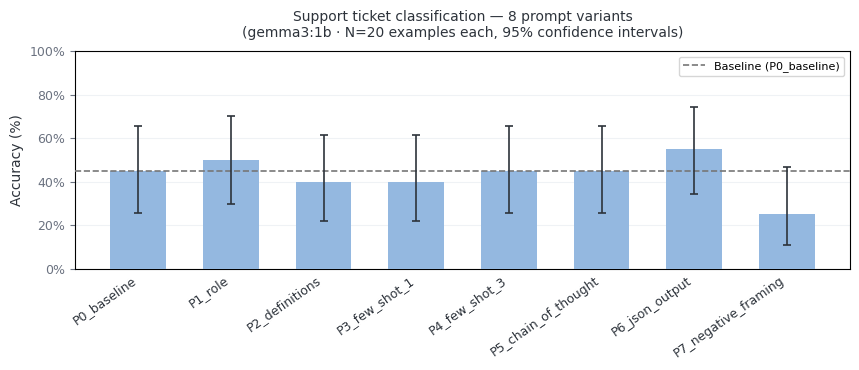

In [2]:
report = pstats.compare_prompts(
    scores,
    simultaneous_ci=True, # This is true by default, but we set it explicitly here for clarity.
    rng=np.random.default_rng(42),
)

report.plot_bars(
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=20 examples each, 95% confidence intervals)"
    ),
)
plt.show()

The error bars tell a different story: all intervals overlap, and no prompt is distinguishable from any other. The apparent rankings are well within sampling noise.

Let's double the eval set and see if more data resolves things.

## Expanding our eval set to N=40 samples

We add more examples (equally across all 4 categories) for a total of N=40 tickets. Re-running the analysis:

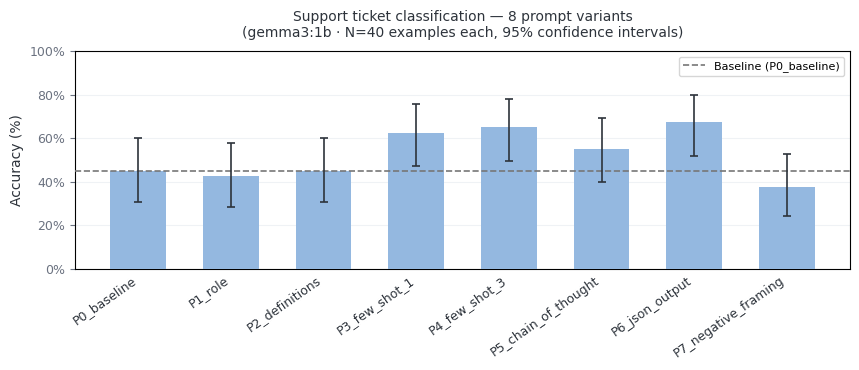

In [3]:
df = pd.read_csv("support_ticket_eval_40.csv")
scores = get_scores_from_df(df)

report = pstats.compare_prompts(
    scores,
    rng=np.random.default_rng(42),
)

report.plot_bars(
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=40 examples each, 95% confidence intervals)"
    ),
)
plt.show()

Slightly clearer. The early lead of `P1_role` appears to have been a fluke; `P3_few_shot_1` now looks stronger. But overlaps remain large, and N=40 still doesn't cleanly separate the field.

You might be thinking: "Wait, so we need more data then? How much more data do we need? You're telling me I need to create benchmark-size dataset just to see a clear difference?"

Actually no, not entirely—there's a better analysis we can perform here.

## Pairwise Comparisons

So far we've plotted each prompt's scores independently. But these aren't independent samples: every prompt was run on the *same* inputs. We can exploit that structure.

**Pairwise comparison** means comparing prompts example by example. For each shared input, we ask: did prompt A get this right when prompt B got it wrong? For each pair, we build a per-input difference table:

| Input | Prompt A | Prompt B | A − B |
|------:|:-:|:-:|:-----:|
| 1     | 1 | 0 | +1    |
| 2     | 0 | 0 | 0     |
| 3     | 1 | 1 | 0     |
| 4     | 0 | 1 | −1    |
| ...   | ... | ... | ... |
| N     | 1 | 0 | +1    |

We then compute the mean difference and its 95% CI. This removes noise from item difficulty — easy items are easy for everyone; hard items are hard for everyone. The analysis focuses on actual prompt differences rather than shared variance.

With 8 prompts there are $\frac{8 \times 7}{2} = 28$ pairwise comparisons. But running all 28 at once creates a new problem:

## The Multiple Comparisons Problem

Each confidence interval carries a 5% chance of a false positive. Running 28 independent CIs means that chance compounds — a phenomenon known as the [**Family-Wise Error Rate (FWER)**](https://en.wikipedia.org/wiki/Family-wise_error_rate). It's so common that [XKCD once made fun of it](https://xkcd.com/882/).

To be precise here, let's calculate the probability of a false positive if we're running 28 tests. Since we have a 95% Confidence Interval for each comparison, our risk of a false positive for any _single_ test is $5%$ ($\alpha = 0.05$). To find the probability of at least one error across **28 comparisons**, we first calculate the probability of all 28 being "correct" (no false positives) and subtract that from 1:
 1.  Probability of no error in one test: $1 - 0.05 = 0.95$
 2.  Probability of no errors in 28 tests: $0.95^{28} \approx 0.2378$
 3.  Probability of at least one false positive: $1 - 0.2378 = 0.7622$

Thus, with 28 comparisons at α = 0.05, the probability of at least one false positive is **76%**. We'd almost certainly be claiming a difference that's purely noise.

## Multiple comparisons correction with simultaneous CIs

The fix is to make your confidence intervals accountable for the *full family* of comparisons, not just each pair in isolation.

`promptstats` uses [**simultaneous confidence intervals**](https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/anova/supporting-topics/multiple-comparisons/understanding-individual-and-simultaneous-confidence-levels/) by default. A standard 95% CI for a single comparison means that one interval covers the true value 95% of the time. A *simultaneous* 95% CI family means that 95% of the time, *all* intervals — across every pairwise comparison — cover their true differences at once. This controls the family-wise error rate directly.

Simultaneous CIs are wider than marginal ones, and the more comparisons you run, the wider they get. The interpretation is direct: **if a simultaneous CI excludes zero, the difference is confirmed; if it straddles zero, the two prompts are indistinguishable** at your confidence level.

> `promptstats` uses the **bootstrap max-T method** for simultaneous CIs by default — less conservative than Bonferroni when comparisons are correlated (typical when all prompts run on the same inputs). For non-bootstrap methods like `newcombe` and `bayes_binary`, it falls back to Bonferroni adjustment. Either way, `simultaneous_ci=True` is the default.

  Prompt                   Mean  95% CI                  Status
  -----------------------------------------------------------------
  P6_json_output         67.5%  [52.0%, 79.9%]          in contention
  P4_few_shot_3          65.0%  [49.5%, 77.9%]          in contention
  P3_few_shot_1          62.5%  [47.0%, 75.8%]          in contention
  P5_chain_of_thought    55.0%  [39.8%, 69.3%]          in contention
  P0_baseline            45.0%  [30.7%, 60.2%]          in contention
  P2_definitions         45.0%  [30.7%, 60.2%]          outperformed
  P1_role                42.5%  [28.5%, 57.8%]          outperformed
  P7_negative_framing    37.5%  [24.2%, 53.0%]          outperformed


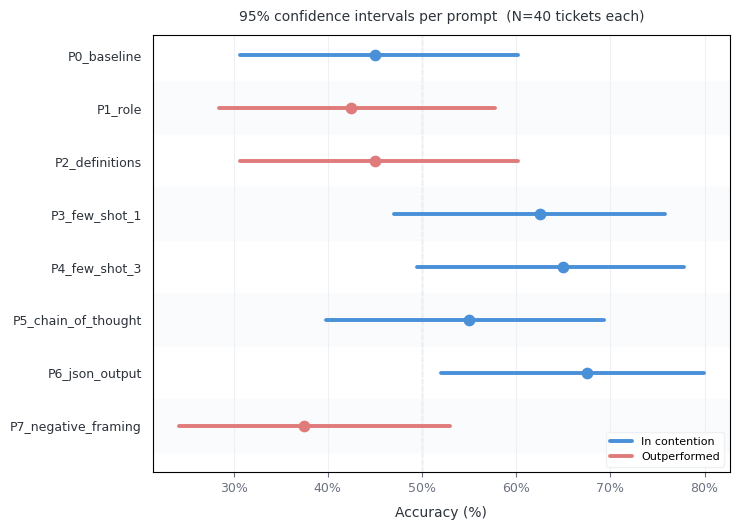

In [4]:
# One score array per prompt (40 binary values each)
scores = {
    p: df[df["prompt_id"] == p]["correct"].tolist()
    for p in PROMPTS
}

# simultaneous_ci=True is the default; set explicitly here for clarity
report = pstats.compare_prompts(
    scores,
    simultaneous_ci=True,
    rng=np.random.default_rng(42),
)

report.print_ci_table(sort_by="mean")

pstats.plot_ci_forest(
    report,
    title="95% confidence intervals per prompt  (N=40 tickets each)",
    sort_by="input_order"
)
plt.show()

Now let's read the full pairwise summary:

In [5]:
report.summary(pairwise_sort="significance")

 PROMPTS COMPARISON 
8 prompts | 40 inputs | method=bayes_binary | 95% confidence intervals (CI)

--- Mean Performance (Wilson CIs) ---
  axis: [-0.179, 1.213]  (· ±1σ, ─ CI, ● mean, │ grand mean)
  Prompt                   Interval Plot                                 Mean    CI Low   CI High
  P0_baseline                  ··········────●─│──···········          0.450    0.307    0.602
  P1_role                     ··········────●──│──··········           0.425    0.285    0.578
  P2_definitions               ··········────●─│──···········          0.450    0.307    0.602
  P3_few_shot_1                     ··········─│──●────··········      0.625    0.470    0.758
  P4_few_shot_3                      ·········─│───●────··········     0.650    0.495    0.779
  P5_chain_of_thought            ···········───│●────··········        0.550    0.398    0.693
  P6_json_output                      ·········│────●───··········     0.675    0.520    0.799
  P7_negative_framing        ··········─

## Reading the Results

The Executive Summary at the end groups prompts into **tiers** based on which simultaneous pairwise CIs exclude zero.

**Top tier (statistically tied):** `P6_json_output`, `P4_few_shot_3`, `P3_few_shot_1`, `P5_chain_of_thought`, `P0_baseline`. Despite spanning raw accuracies from 45.0% to 67.5%, these five are *indistinguishable* at N=40 — every pairwise CI within this group straddles zero.

**Confirmed underperformers:** `P2_definitions` (45.0%), `P1_role` (42.5%), and `P7_negative_framing` (37.5%) are significantly worse than the top tier. Their pairwise difference CIs versus P6 all exclude zero. Three common prompt patterns — definition-heavy, role-only, and negative/contrastive framing — genuinely hurt performance on this model.

**What about `P6_json_output`'s 22-point lead over `P0_baseline`?** The pairwise CI between them straddles zero. At N=40, that gap isn't distinguishable from noise.

> **Why do some CIs appear red (underperformed) even when they visually overlap blue ones?** The forest plot shows *per-prompt* accuracy CIs — "where does this prompt's true accuracy lie?" Tier colors come from *pairwise difference* CIs — "does the CI for A minus B exclude zero?" These are different objects. Per-prompt CIs can visually overlap while the pairwise difference CI still excludes zero, because the shared test set gives extra precision on the *difference*. If two CIs overlap but one is red, check the Pairwise Comparisons section. (This is also why it's nice to have a stats analysis tool—there's so many pairwise comparisons here, it's hard to see what's going on. The Executive Summary and rank bands explain the TLDR.)

## Critical Difference Diagrams

The "statistically indistinguishable rank bands" part of the pairwise summary can also be visualized as a [critical difference diagram](https://mirkobunse.github.io/CriticalDifferenceDiagrams.jl/dev/), introduced by Janez Demšar in [Statistical Comparisons of Classifiers over Multiple Data Sets](https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf). `promptstats` can plot one directly:

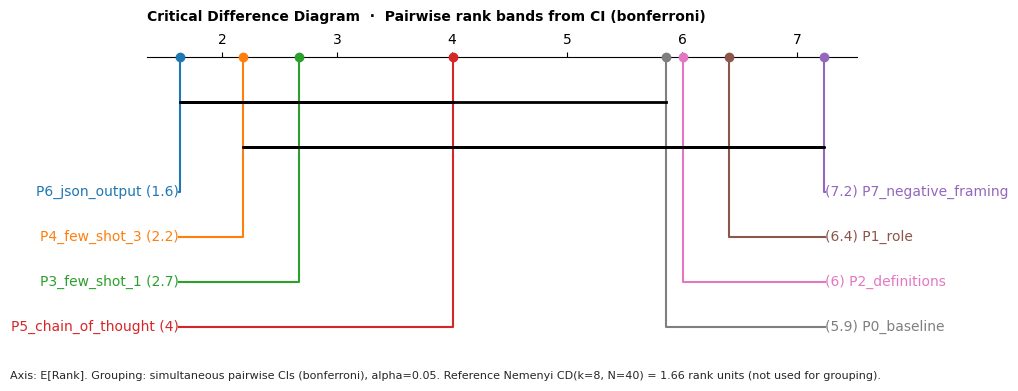

In [6]:
pstats.plot_critical_difference(report)
plt.show()

The rank bands match what the pairwise summary reported: we have five leaders that can't be distinguished from one another, followed by a group of 7 (the rest), but you'll notice a big overlap—this is normal, even if it's non-intuitive. It means that we can't say the elements of that rank band are significantly different from one another, statistically speaking.

What the diagram makes visually clear is that P6 leads, and is well separated from P2, P1, and P7. But exactly *how* far ahead it is — that's still an open question at N=40.

> **What do the numbers mean?**: Here we've done something fancy—to be consistent with our estimation-based statistics philosophy that emphasizes CIs and resampling rather than p-values, we've used E[rank], which uses bootstrap resampling to estimate rank probabilities per each prompt. In Demsar's initial paper, you compute these values from the Friedman test. However, the Friedman test is an omnibus test used in a null-hypothesis testing framework—that's inconsistent with [our philosophy here](../principles.html) and it's also inconsistent with the way we computed the rank bands, which used simultaneous CIs rather than the p-values. Thus, here `promptstats` is doing the "estimation statistics" equivalent of CD diagrams. By the way, if you had set `omnibus=True`, `promptstats` would have used the Friedman test information instead.

## Expanding the eval set and adding multiple runs to improve power

Our CIs were wide for two reasons: only 40 tickets, and possible run-to-run stochasticity at temperature > 0. We tackle both at once.

Imagine we've now rebuilt the eval set with **120 tickets** (30 per category): the original 10 clear-cut examples per category, 10 harder **boundary cases** that straddle two categories, and 10 **adversarial cases** that use surface framing designed to mislead simpler prompts. For example:

| Ticket | Looks like | Actually |
|--------|-----------|----------|
| "The feature I upgraded for last month never worked — I'd like a credit." | TECHNICAL | **BILLING** |
| "2FA codes never arrive by SMS, no matter how many retries." | ACCOUNT | **TECHNICAL** |
| "What's the difference between Owner, Admin, and Member roles?" | ACCOUNT | **GENERAL** |
| "After rotating my API key, all production integrations broke." | ACCOUNT | **TECHNICAL** |
| "You charged me twice and your team keeps closing my ticket without fixing it." | BILLING | **GENERAL** |

We also ran each (prompt, ticket) pair **5 times** at temperature=1.0. 

Do we have enough data to pick a winner now? Let's start by checking run-to-run consistency:

In [7]:
# Load the multi-run CSV (one row per prompt x ticket x run)
df_mr = pd.read_csv("support_ticket_eval_multirun.csv")

# Accuracy per (prompt, run) — if scores are flat across runs,
# run-to-run variance is low and extra runs won't tighten CIs much
run_acc = (
    df_mr.groupby(["prompt_id", "run_idx"])["correct"]
    .mean()
    .unstack("run_idx")
    .loc[PROMPTS]
)
run_acc.columns = [f"run {c}" for c in run_acc.columns]
run_acc["mean"] = run_acc.mean(axis=1)
run_acc["std"]  = run_acc.iloc[:, :5].std(axis=1)

print("Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):")
print(run_acc.to_string(float_format="{:.1%}".format))

Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):
                     run 1  run 2  run 3  run 4  run 5  mean  std
prompt_id                                                        
P0_baseline          42.5%  45.8%  44.2%  44.2%  44.2% 44.2% 1.2%
P1_role              40.8%  40.0%  44.2%  40.8%  42.5% 41.7% 1.7%
P2_definitions       38.3%  38.3%  38.3%  39.2%  38.3% 38.5% 0.4%
P3_few_shot_1        51.7%  51.7%  52.5%  52.5%  51.7% 52.0% 0.5%
P4_few_shot_3        54.2%  54.2%  52.5%  52.5%  52.5% 53.2% 0.9%
P5_chain_of_thought  48.3%  49.2%  44.2%  46.7%  47.5% 47.2% 1.9%
P6_json_output       55.8%  55.8%  57.5%  55.8%  56.7% 56.3% 0.7%
P7_negative_framing  34.2%  30.8%  34.2%  32.5%  31.7% 32.7% 1.5%


Even with 120 harder examples, the model is highly consistent across runs: most prompts have std below 1%, with `P5_chain_of_thought` the highest at ~2%. Run-to-run variance is not the bottleneck here.

> Potentially, this is because gemma3:1b is a very small model. If we had a very large model with hundreds of billions of parameters, we might see higher variance. Of course, we'd expect to see higher performance, as well!

The harder examples are doing work, though: rankings are spreading out. `P6_json_output` leads the field at 56.3%, while `P2_definitions` drops to 38.5%. The adversarial cases in particular reveal that structured prompts (few-shot, JSON output) handle ambiguous inputs far better than definition-heavy or negatively-framed ones.

Let's plot the new confidence intervals, compared to the old ones when N=40, to check what happened:

Prompt                        40T · 1R    120T · 1R    120T · 5R    Δ tickets     Δ runs
----------------------------------------------------------------------------------------
P0_baseline                       29.5%       17.4%       17.5%       -12.0%    +0.1%
P1_role                           29.3%       17.3%       17.4%       -12.0%    +0.1%
P2_definitions                    29.5%       17.1%       17.1%       -12.3%    +0.0%
P3_few_shot_1                     28.7%       17.6%       17.6%       -11.1%    +0.0%
P4_few_shot_3                     28.4%       17.6%       17.6%       -10.8%    +0.0%
P5_chain_of_thought               29.5%       17.6%       17.6%       -11.9%    -0.0%
P6_json_output                    27.9%       17.5%       17.5%       -10.4%    -0.0%
P7_negative_framing               28.7%       16.7%       16.5%       -12.0%    -0.2%


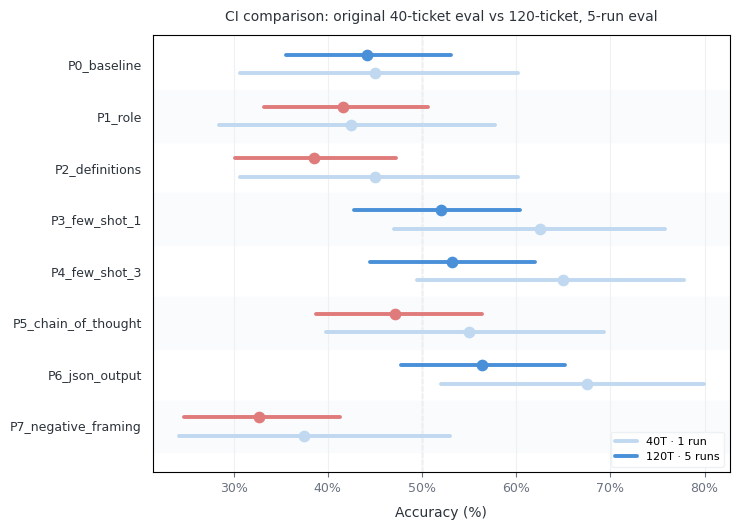

In [8]:
# Reshape to {prompt: array of shape (120 tickets, 5 runs)}
scores_mr = {
    p: (
        df_mr[df_mr["prompt_id"] == p]
        .pivot(index="input_id", columns="run_idx", values="correct")
        .values.tolist()
    )
    for p in PROMPTS
}
report_mr = pstats.compare_prompts(
    scores_mr,
    correction="holm",
    rng=np.random.default_rng(42),
)

# 120-ticket single-run (run 1 only) — for the three-way CI width comparison
df_1run = df_mr[df_mr["run_idx"] == 1]
scores_1run = {p: df_1run[df_1run["prompt_id"] == p]["correct"].tolist() for p in PROMPTS}
report_1run = pstats.compare_prompts(
    scores_1run,
    correction="holm",
    rng=np.random.default_rng(42),
)

# Three-way CI width table: original 40T/1R  ->  120T/1R  ->  120T/5R
header = f"{'Prompt':<28}  {'40T · 1R':<10}  {'120T · 1R':<11}  {'120T · 5R':<11}  {'Δ tickets':<12}  {'Δ runs'}"
print(header)
print("-" * len(header))
for p in PROMPTS:
    s0 = report.model_stats[p]        # original 40-ticket eval (cell 5)
    s1 = report_1run.model_stats[p]
    s5 = report_mr.model_stats[p]
    w0 = s0.ci_high - s0.ci_low
    w1 = s1.ci_high - s1.ci_low
    w5 = s5.ci_high - s5.ci_low
    print(f"{p:<28}  {w0:>9.1%}  {w1:>10.1%}  {w5:>10.1%}  {w1 - w0:>+11.1%}  {w5 - w1:>+7.1%}")

# Forest plot: 40T single-run (light) vs 120T 5-run (coloured by tier)
pstats.plot_ci_forest(
    report_mr,
    compare_to=report,
    report_label="120T · 5 runs",
    compare_label="40T · 1 run",
    title="CI comparison: original 40-ticket eval vs 120-ticket, 5-run eval",
    sort_by="input_order"
)
plt.show()

Notice how much tighter the dark intervals are in the plot: those are the 120-ticket, 5-run CIs, compared against the lighter original 40-ticket CIs for the same prompts.

The main effect is from more (and harder) eval items. Extra runs help a little (if we plotted this, we would see), but the CI tightening here is dominated by expanding the eval set. This is actually a lessen for us: if we had to choose between getting more samples on the same items, versus expanding our eval set, we should do the latter every time. (Of course, the latter requires much more effort on our part!)

Also notice that our original CI estimates for `P6_json_output`, `P3_few_shot_1`, etc., were over-confident. Or were they?

When we expanded our test set with harder examples, performance flattened a bit across the board. Still, though, the JSON output prompt seems to lead. Let's output a full summary to check which are the likely winners.

In [9]:
report_mr.full_summary(pairwise_sort="significance")

Shape: BenchmarkShape(models=1, prompts=8, input_vars=1, evaluators=1, runs=5)
Templates: 8 | Inputs: 120 | Runs: 5

--- Robustness ---
                         mean  median       std        cv  iqr  cvar_10  p10  p25  p50  p75  p90
template                                                                                        
P0_baseline          0.441667     0.2  0.476610  1.079116  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P1_role              0.416667     0.0  0.463515  1.112435  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P2_definitions       0.385000     0.0  0.487258  1.265605  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P3_few_shot_1        0.520000     1.0  0.499681  0.960924  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P4_few_shot_3        0.531667     1.0  0.492291  0.925939  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P5_chain_of_thought  0.471667     0.2  0.478651  1.014807  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P6_json_output       0.563333     1.0  0.493305  0.875690  1.0      0.0  0.0  0.0  1.0  

Three tiers have now emerged. For `P6_json_output`, the simultaneous 95% CI on its pairwise difference versus each of P1, P2, P5, and P7 excludes zero—meaning we can conclude, at this stage, that P6 is better than those four. The top-tier prompts, by contrast, are not yet distinguishable from each other: their pairwise difference CIs all straddle zero.

Once again, we can see the rank band info with a critical difference plot, too:

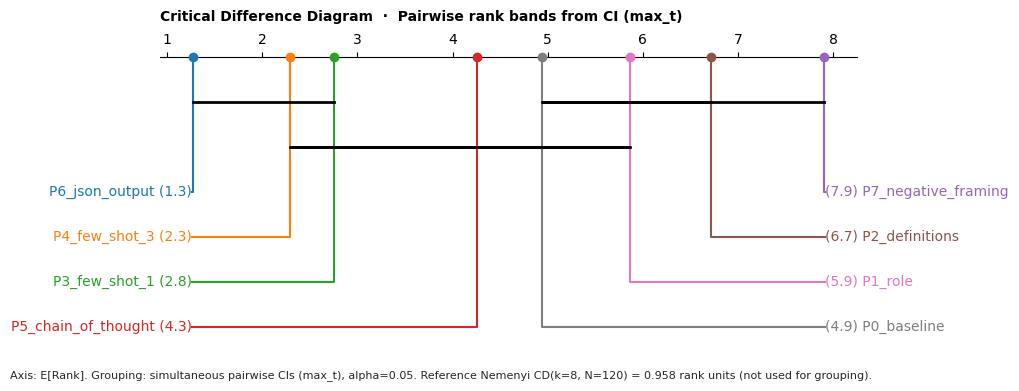

In [10]:
pstats.plot_critical_difference(report_mr)
plt.show()

At this stage, we'd drop P1, P2, P7, and P0 and focus iteration on the top-tier candidates. This mirrors the logic behind evolutionary prompt optimization algorithms like [EvoPrompt](https://arxiv.org/abs/2309.08532) and [PromptBreeder](https://arxiv.org/abs/2309.16797): identify weak variants, cull them, and mutate the strong ones. A complementary step is a *reflection pass* — have an LLM review misclassified tickets, identify failure patterns, and propose targeted prompt revisions. But that's for another investigation.

> The major difference here with evolutionary algorithms is that we're actually computing stats over our point estimates. We aren't, for instance, greedily taking the mean over a few samples and concluding "Variation A wins, let's drop B." Our analysis has shown us that that's actually full of noise—so it's likely that any prompt optimization algorithm that works that way, has to work against a lot of noise, which might in the end lead to subpar outcomes. Food for thought.

## Conclusion: What Worked, What Misled

What did we learn? 

Whenever you compare prompts, you should run pairwise comparisons across the same inputs, correcting for FWER. A raw bar chart without error bars will almost always look decisive. Adding CIs made the actual state of knowledge visible: at N=40, only confirmed losers could be identified; resolving the top tier required more data. To gain more power, we needed to run pairwise comparisons to compute CIs. But to do that, we also need to correct for the FWER—even when comparing just 8 prompts with 95% CIs, there's a 76% false-positive risk. That also opened us up to the fact that visuals can mislead—really, even if CIs on means overlap slightly when plotted as error bars, this isn't the same as CIs on pairwise comparisons, which are harder to visualize but statistically, more powerful and more appropriate in this setting. 

We also learned a couple lessons for the future:

* **Expanding the eval set made the biggest difference.** Going from 40 to 120 tickets cut CI widths by roughly 10–13 percentage points per prompt. Harder boundary and adversarial examples do double duty: they add statistical power *and* stress-test prompts in the regime where real differences show up. Easy examples inflate accuracy and can make weak prompts look better than they are.

* **Multiple runs weren't the bottleneck.** Run-to-run variance was low (std ≈ 0–2%), so extra runs trimmed only ~1 pp off most CIs. This isn't always true — for generative tasks or higher-variance models, run-to-run noise can dominate. **Check variance first:** if per-prompt std is low, spend your budget on eval coverage; if it's high, add runs before expanding tickets.

We also learned an iterative workflow for how to make decisions in a statistically principled manner:

1. **Eliminate losers early.** Don't try to pick a winner at modest N — use simultaneous CIs to *eliminate confirmed losers* instead. At N=40, P1, P2, and P7 were already separable from the top tier. Drop them and save on cost.
2. **Harden test sets when scaling.** When you expand your eval set, composition matters as much as count. Boundary and adversarial cases reveal differences that homogeneous examples mask.
3. **Repeat until leaders separate.** At 120T/5R, a three-tier structure emerged. The right conclusion isn't "P6 wins" but "drop the bottom tier; treat P6, P4, and P3 as co-leaders for the next iteration."